# 1) Chargement des données

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../Ressources/billets.csv"

if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")
    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)


✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


# 2) Analyse exploratoire (EDA)


In [2]:
print("Le tableau comporte {} ligne(s)".format(df.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df.shape[1]))

Le tableau comporte 1500 ligne(s)
Le tableau comporte 7 colonne(s)


In [3]:
df.isnull().sum()

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

In [4]:
print(df.duplicated().sum())

0


In [5]:
df.describe().loc[['count', 'mean', 'min', 'max']]

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.00000,1500.000000,1500.000000,1463.000000,1500.000000,1500.0000
mean,171.95844,104.029533,103.920307,4.485967,3.151473,112.6785
min,171.04000,103.140000,102.820000,2.980000,2.270000,109.4900
max,173.01000,104.880000,104.950000,6.900000,3.910000,114.4400


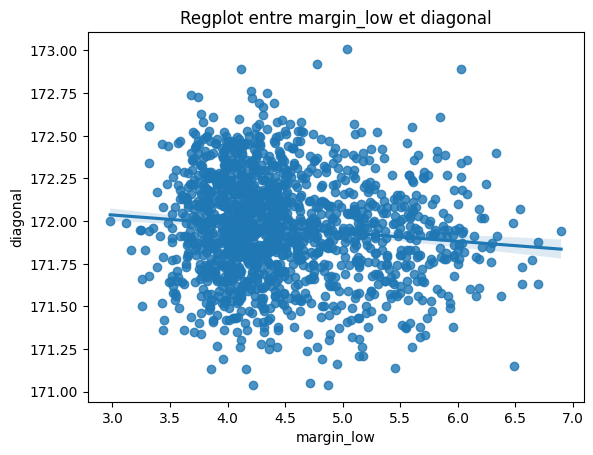

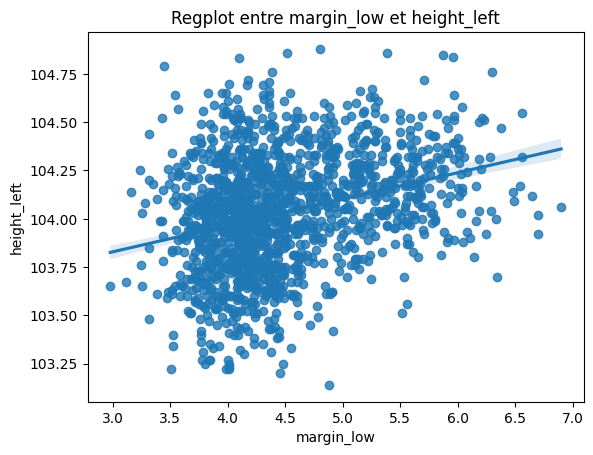

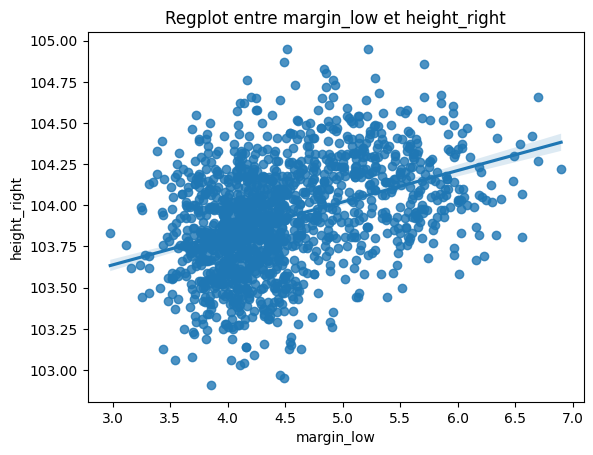

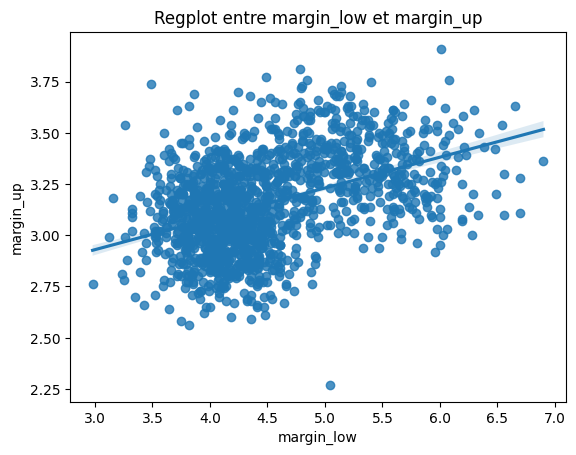

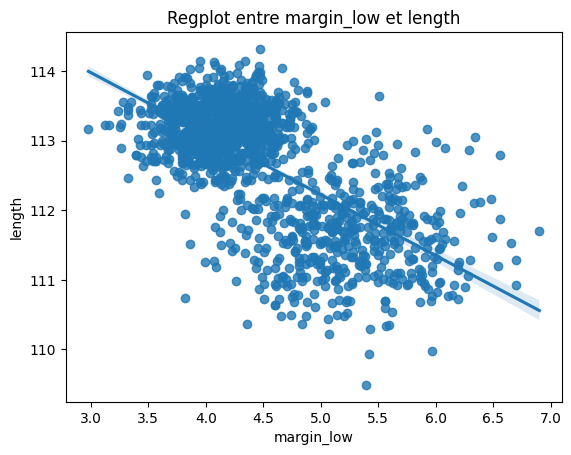

In [6]:
import seaborn as sns
for col in df.columns:
    if col != 'margin_low' and col != 'is_genuine':
        sns.regplot(x=df['margin_low'], y=df[col])
        plt.title(f'Regplot entre margin_low et {col}')
        plt.show()

In [7]:
import scipy.stats as stats

correlations = {}
df_temp = df[df['margin_low'].notnull()]

for col in df_temp.columns:
    if col != 'margin_low' and col != 'is_genuine':
        corr, p_value = stats.pearsonr(df_temp['margin_low'].dropna(), df_temp[col].dropna())
        correlations[col] = (corr, p_value)

for col, (corr, p_value) in correlations.items():
    print(f"Corrélation entre margin_low et {col} : {corr:.4f} (p-value: {p_value:.4f})")

seuil_correlation = 0.5
variables_selectionnees = [col for col, (corr, p_value) in correlations.items() if abs(corr) >= seuil_correlation]
print("Variables sélectionnées pour le modèle de régression linéaire :", variables_selectionnees)

Corrélation entre margin_low et diagonal : -0.1115 (p-value: 0.0000)
Corrélation entre margin_low et height_left : 0.3026 (p-value: 0.0000)
Corrélation entre margin_low et height_right : 0.3911 (p-value: 0.0000)
Corrélation entre margin_low et margin_up : 0.4316 (p-value: 0.0000)
Corrélation entre margin_low et length : -0.6668 (p-value: 0.0000)
Variables sélectionnées pour le modèle de régression linéaire : ['length']


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df_train = df[df['margin_low'].notnull()]
df_test = df[df['margin_low'].isnull()]

X = df_train[['length']]
y = df_train['margin_low']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

from sklearn.metrics import mean_absolute_percentage_error
mse = mean_absolute_percentage_error(y_val, y_pred)
print("Mean Absolute Percentage Error:", mse)

X_test = df_test[['length']]
df.loc[df['margin_low'].isnull(), 'margin_low'] = model.predict(X_test)

print("Valeurs manquantes dans 'margin_low' après imputation :", df['margin_low'].isnull().sum())

Mean Absolute Percentage Error: 0.07712090460081912
Valeurs manquantes dans 'margin_low' après imputation : 0


In [9]:
from scipy.stats import zscore  
numeric_cols = df.select_dtypes(include=[np.number]).columns
z_scores = df[numeric_cols].apply(zscore)
outliers = (np.abs(z_scores) > 3).any(axis=1)
print("Nombre de valeurs aberrantes détectées :", outliers.sum())

print(df[outliers])

Nombre de valeurs aberrantes détectées : 24
      is_genuine  diagonal  height_left  height_right  margin_low  margin_up  \
0           True    171.81       104.86        104.95    4.520000       2.89   
251         True    171.80       103.26        102.82    4.212455       2.95   
522         True    172.02       104.42        102.91    3.860000       3.12   
664         True    172.05       103.70        103.75    5.040000       2.27   
729         True    171.04       103.84        103.64    4.220000       3.36   
828         True    172.92       103.55        103.94    4.780000       3.27   
842         True    172.89       103.77        104.24    4.120000       3.01   
1022       False    172.89       104.03        104.03    6.030000       3.00   
1027       False    171.63       104.02        104.66    6.700000       3.28   
1029       False    171.96       104.29        104.03    6.010000       3.91   
1041       False    171.77       104.12        104.42    6.650000       3.63

In [10]:
df.describe().loc[['count', 'mean', 'min', 'max']]

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.0000
mean,171.95844,104.029533,103.920307,4.484064,3.151473,112.6785
min,171.04000,103.140000,102.820000,2.980000,2.270000,109.4900
max,173.01000,104.880000,104.950000,6.900000,3.910000,114.4400


In [11]:
import scipy.stats as stats
features = []
for col in df.columns:
    if col != 'is_genuine':
        group1 = df[df['is_genuine'] == 0][col]
        group2 = df[df['is_genuine'] == 1][col]
        t_stat, p_value = stats.ttest_ind(group1, group2, nan_policy='omit')
        if p_value < 0.05:
            features.append(col)
            print(f"La feature '{col}' est importante (p-value: {p_value:.4f})")
print("Features importantes:", features)

La feature 'diagonal' est importante (p-value: 0.0000)
La feature 'height_left' est importante (p-value: 0.0000)
La feature 'height_right' est importante (p-value: 0.0000)
La feature 'margin_low' est importante (p-value: 0.0000)
La feature 'margin_up' est importante (p-value: 0.0000)
La feature 'length' est importante (p-value: 0.0000)
Features importantes: ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']


# 3) Prétraitement


In [12]:
X = df[features]
y = df["is_genuine"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4) Modélisation

* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_lr_pred = lr_model.predict(X_test)
print(lr_model.predict_proba(X_test))

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

lr_accuracy = accuracy_score(y_test, y_lr_pred)
lr_classification_report = classification_report(y_test, y_lr_pred)
lr_confusion_matrix = confusion_matrix(y_test, y_lr_pred)
lr_roc_auc = roc_auc_score(y_test, y_lr_pred)

[[9.11776048e-04 9.99088224e-01]
 [9.99969276e-01 3.07236214e-05]
 [9.99969229e-01 3.07707032e-05]
 [3.43895392e-01 6.56104608e-01]
 [2.20466250e-03 9.97795338e-01]
 [2.67668293e-04 9.99732332e-01]
 [3.27611392e-03 9.96723886e-01]
 [8.18322994e-05 9.99918168e-01]
 [9.41359147e-04 9.99058641e-01]
 [1.41332708e-02 9.85866729e-01]
 [9.99542541e-01 4.57459128e-04]
 [4.81826053e-04 9.99518174e-01]
 [9.96385485e-01 3.61451532e-03]
 [9.99673868e-01 3.26131627e-04]
 [1.23635555e-03 9.98763644e-01]
 [9.99929370e-01 7.06302224e-05]
 [6.09869681e-03 9.93901303e-01]
 [5.79723566e-02 9.42027643e-01]
 [2.85505749e-04 9.99714494e-01]
 [8.63285337e-03 9.91367147e-01]
 [9.58774561e-01 4.12254389e-02]
 [9.99985024e-01 1.49764264e-05]
 [9.99950136e-01 4.98642673e-05]
 [1.62728703e-03 9.98372713e-01]
 [8.08249850e-01 1.91750150e-01]
 [5.11484545e-05 9.99948852e-01]
 [1.23907708e-04 9.99876092e-01]
 [9.99753830e-01 2.46170031e-04]
 [3.75966935e-06 9.99996240e-01]
 [9.99061524e-01 9.38476068e-04]
 [9.808989

In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_knn_pred = knn_model.predict(X_test)
print(knn_model.predict_proba(X_test))

knn_accuracy = accuracy_score(y_test, y_knn_pred)
knn_classification_report = classification_report(y_test, y_knn_pred)
knn_confusion_matrix = confusion_matrix(y_test, y_knn_pred)
knn_roc_auc = roc_auc_score(y_test, y_knn_pred)

[[0.  1. ]
 [1.  0. ]
 [1.  0. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [1.  0. ]
 [0.  1. ]
 [1.  0. ]
 [1.  0. ]
 [0.  1. ]
 [1.  0. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [1.  0. ]
 [1.  0. ]
 [1.  0. ]
 [0.  1. ]
 [0.8 0.2]
 [0.  1. ]
 [0.  1. ]
 [1.  0. ]
 [0.  1. ]
 [1.  0. ]
 [1.  0. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [1.  0. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [1.  0. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [1.  0. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [1.  0. ]
 [0.  1. ]
 [0.  1. ]
 [1.  0. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.6 0.4]
 [1.  0. ]
 [1.  0. ]
 [1.  0. ]
 [1.  0. ]
 [1.  0. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [1.  0. ]
 [1.  0. ]
 [1.  0. ]
 [0.  1. ]
 [1.  0. ]
 [1.  0. ]
 [0.  1. ]
 [1.  0. ]
 [0.  1. ]
 [1.  0. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [1.  0. ]
 [0.  1. ]
 [1.  0. ]
 [0.4 0.6]
 [1.  0. ]
 [1.  0. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [1.  0. ]

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)
print(rf_model.predict_proba(X_test))

rf_accuracy = accuracy_score(y_test, y_rf_pred)
rf_classification_report = classification_report(y_test, y_rf_pred)
rf_confusion_matrix = confusion_matrix(y_test, y_rf_pred)
rf_roc_auc = roc_auc_score(y_test, y_rf_pred)

[[0.   1.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.04 0.96]
 [0.   1.  ]
 [0.   1.  ]
 [0.   1.  ]
 [0.   1.  ]
 [0.   1.  ]
 [0.03 0.97]
 [1.   0.  ]
 [0.   1.  ]
 [0.93 0.07]
 [1.   0.  ]
 [0.04 0.96]
 [1.   0.  ]
 [0.08 0.92]
 [0.03 0.97]
 [0.   1.  ]
 [0.   1.  ]
 [0.92 0.08]
 [0.99 0.01]
 [1.   0.  ]
 [0.01 0.99]
 [0.6  0.4 ]
 [0.   1.  ]
 [0.   1.  ]
 [1.   0.  ]
 [0.   1.  ]
 [0.99 0.01]
 [0.99 0.01]
 [0.   1.  ]
 [0.   1.  ]
 [0.03 0.97]
 [1.   0.  ]
 [0.   1.  ]
 [0.02 0.98]
 [0.02 0.98]
 [0.01 0.99]
 [0.63 0.37]
 [0.   1.  ]
 [0.   1.  ]
 [0.   1.  ]
 [1.   0.  ]
 [0.   1.  ]
 [0.   1.  ]
 [0.   1.  ]
 [0.13 0.87]
 [1.   0.  ]
 [0.1  0.9 ]
 [0.04 0.96]
 [0.99 0.01]
 [0.   1.  ]
 [0.   1.  ]
 [0.   1.  ]
 [0.27 0.73]
 [0.98 0.02]
 [0.99 0.01]
 [0.98 0.02]
 [1.   0.  ]
 [1.   0.  ]
 [0.   1.  ]
 [0.01 0.99]
 [0.17 0.83]
 [0.   1.  ]
 [0.86 0.14]
 [0.83 0.17]
 [1.   0.  ]
 [0.   1.  ]
 [0.84 0.16]
 [0.99 0.01]
 [0.   1.  ]
 [1.   0.  ]
 [0.01 0.99]
 [0.85 0.15]
 [0.   1.  ]
 [0.08 0.92]

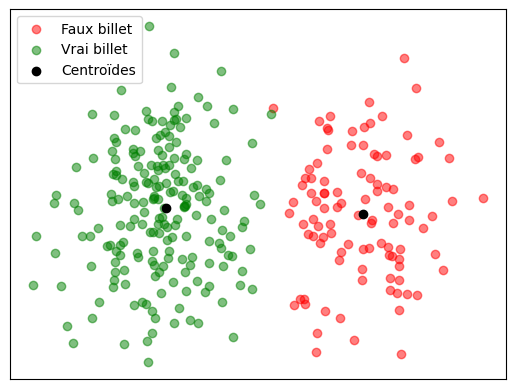

In [18]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)
y_kmeans_pred = kmeans.predict(X_test)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)
centroids = pca.transform(kmeans.cluster_centers_)

colors = {True: 'green', False: 'red'}
for value in np.unique(y_kmeans_pred):
    label = "Vrai billet" if value else "Faux billet"
    plt.scatter(X_pca[y_kmeans_pred == value, 0], X_pca[y_kmeans_pred == value, 1], c=colors[bool(value)], label=label, alpha=0.5)

plt.scatter(centroids[:, 0], centroids[:, 1], c='black', label='Centroïdes')
plt.xticks([])
plt.yticks([])
plt.legend()
plt.show()

In [19]:
kmeans_accuracy = accuracy_score(y_test, y_kmeans_pred)
kmeans_classification_report = classification_report(y_test, y_kmeans_pred)
kmeans_confusion_matrix = confusion_matrix(y_test, y_kmeans_pred)
kmeans_roc_auc = roc_auc_score(y_test, y_kmeans_pred)

# Sélection du meilleur modèle

* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)


* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

Résultats de la régression logistique :
Accuracy: 0.99
Matrix:


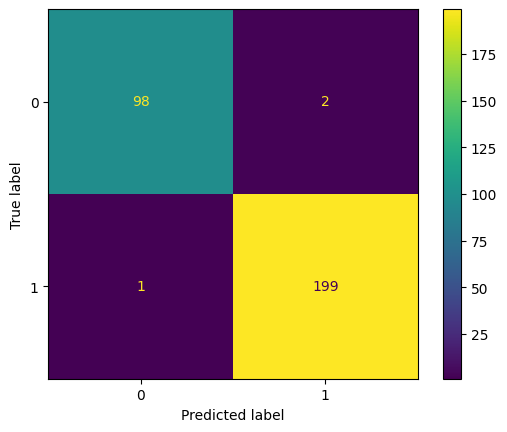

ROC/AUC Score: 0.99
Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [21]:
print("Résultats de la régression logistique :")
print(f"Accuracy: {lr_accuracy:.2f}")
print("Matrix:")
ConfusionMatrixDisplay(confusion_matrix=lr_confusion_matrix).plot()
plt.show()
print(f"ROC/AUC Score: {lr_roc_auc:.2f}")
print("Classification Report:")
print(lr_classification_report)

Résultats du KNN :
Accuracy: 0.98
Matrix:


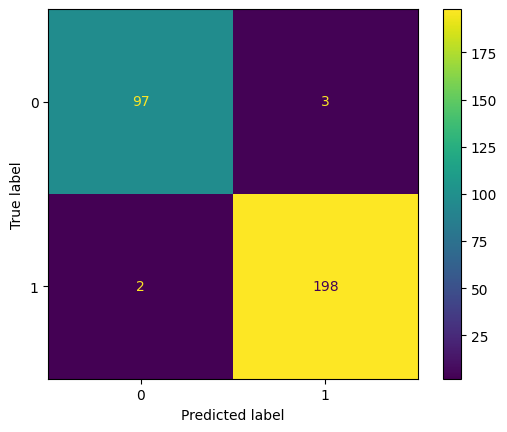

ROC/AUC Score: 0.98
Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.97      0.97       100
        True       0.99      0.99      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



In [22]:
print("Résultats du KNN :")
print(f"Accuracy: {knn_accuracy:.2f}")
print("Matrix:")
ConfusionMatrixDisplay(confusion_matrix=knn_confusion_matrix).plot()
plt.show()
print(f"ROC/AUC Score: {knn_roc_auc:.2f}")
print("Classification Report:")
print(knn_classification_report)

Résultats du Random Forest :
Accuracy: 0.99
Matrix:


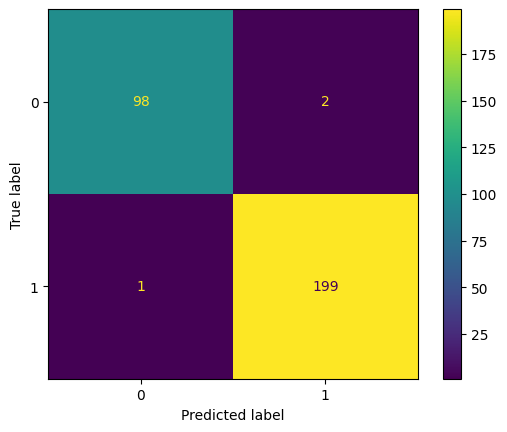

ROC/AUC Score: 0.99
Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [23]:
print("Résultats du Random Forest :")
print(f"Accuracy: {rf_accuracy:.2f}")
print("Matrix:")
ConfusionMatrixDisplay(confusion_matrix=rf_confusion_matrix).plot()
plt.show()
print(f"ROC/AUC Score: {rf_roc_auc:.2f}")
print("Classification Report:")
print(rf_classification_report)

Adjusted Rand Index entre les clusters KMeans et les vraies étiquettes : 0.9465770623742454
Résultats du Kmeans clustering :
Accuracy: 0.99
Matrix:


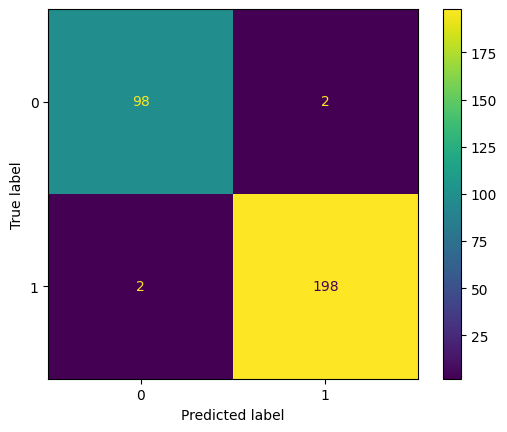

ROC/AUC Score: 0.98
Classification Report:
              precision    recall  f1-score   support

       False       0.98      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300



In [24]:
from sklearn.metrics import adjusted_rand_score
ari_score = adjusted_rand_score(y_test, y_kmeans_pred)
print("Adjusted Rand Index entre les clusters KMeans et les vraies étiquettes :", ari_score)

print("Résultats du Kmeans clustering :")
print(f"Accuracy: {kmeans_accuracy:.2f}")
print("Matrix:")
ConfusionMatrixDisplay(confusion_matrix=kmeans_confusion_matrix).plot()
plt.show()
print(f"ROC/AUC Score: {kmeans_roc_auc:.2f}")
print("Classification Report:")
print(kmeans_classification_report)

# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

In [25]:
from sklearn.pipeline import make_pipeline
import joblib

pipeline = make_pipeline(scaler,rf_model)

joblib.dump(pipeline, 'Weng_Tony_2_modèle_112025.pkl')

['Weng_Tony_2_modèle_112025.pkl']